原子符号: ['C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']
初始坐标（已扰动 ±0.5 Å）:
 [[-1.07891507  0.49851852  0.27449332]
 [ 0.58657717 -0.66552068 -0.53305522]
 [ 0.83506114  0.69095982  0.83878825]
 [-1.14894003  0.25455969 -0.26331271]
 [-1.2608783  -1.15023072 -0.29641556]
 [-1.38762677  0.4006816   1.03591919]
 [ 0.71935107 -0.34937954 -1.12392143]
 [ 0.22952174 -1.63396501 -0.17766864]
 [ 1.78855985  1.333001    0.08865603]]
L-BFGS 优化开始
Iter   0: Energy = -153.09560330 Hartree, |grad| = 1.257
Iter   1: Energy = -153.40591597 Hartree, |grad| = 0.355
Iter   2: Energy = -153.47549296 Hartree, |grad| = 0.324
Iter   3: Energy = -153.54325949 Hartree, |grad| = 0.294
Iter   4: Energy = -153.67618591 Hartree, |grad| = 0.234
Iter   5: Energy = -153.72884468 Hartree, |grad| = 0.200
Iter   6: Energy = -153.78031233 Hartree, |grad| = 0.168
Iter   7: Energy = -153.81596310 Hartree, |grad| = 0.212
Iter   8: Energy = -153.85365612 Hartree, |grad| = 0.178
Iter   9: Energy = -153.87939961 Hartree, |grad| = 0

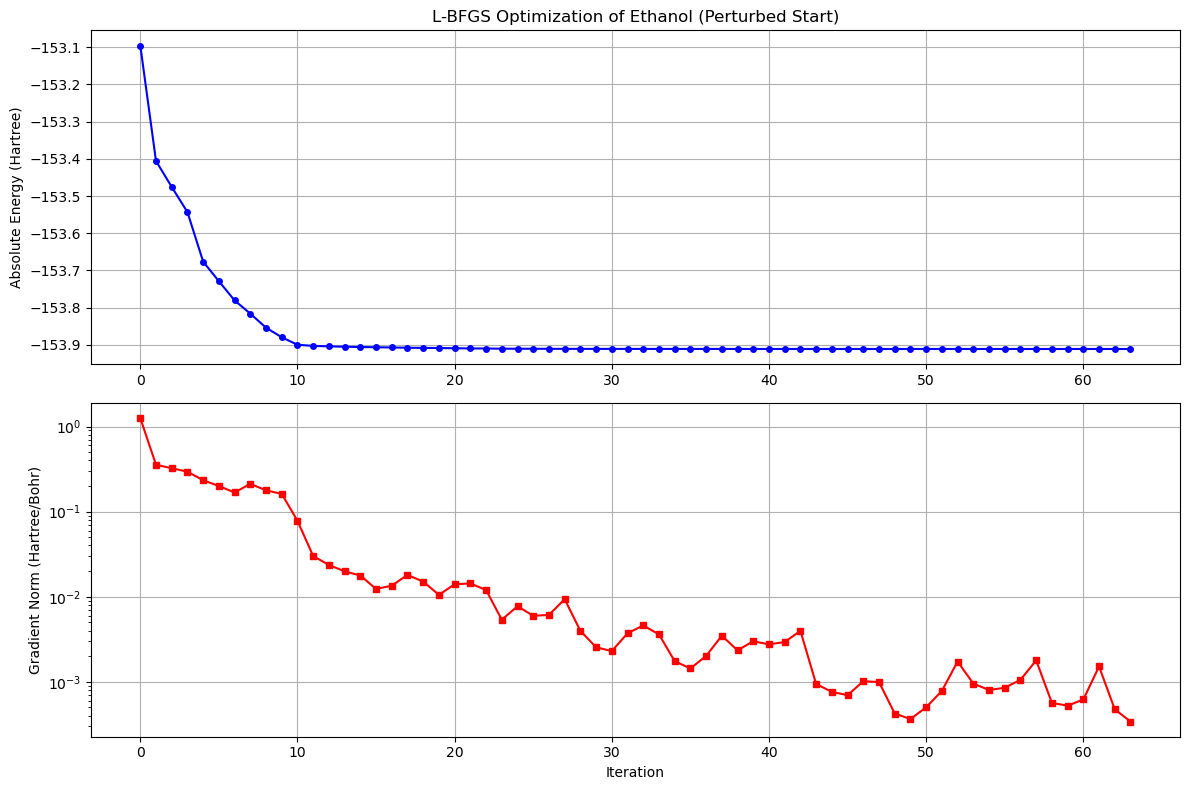

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pyscf import gto, scf, grad
from rdkit import Chem
from rdkit.Chem import AllChem
import warnings
warnings.filterwarnings('ignore')

# ------------------ 1. 生成乙醇初始分子（带扰动） ------------------
def get_ethanol_init(seed=42, perturb_strength=0.0):
    mol = Chem.MolFromSmiles('CCO')
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=seed)
    atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    conf = mol.GetConformer()
    coords = conf.GetPositions()
    if perturb_strength > 0:
        np.random.seed(seed)
        perturbation = np.random.uniform(-perturb_strength, perturb_strength, size=coords.shape)
        coords += perturbation
    return mol, atom_symbols, coords

# 设置扰动强度
perturb = 0.5
mol_rdkit, atom_symbols, init_coords_ang = get_ethanol_init(seed=42, perturb_strength=perturb)
natom = len(atom_symbols)
print("原子符号:", atom_symbols)
print(f"初始坐标（已扰动 ±{perturb} Å）:\n", init_coords_ang)

# ------------------ 2. PySCF 能量和梯度计算 ------------------
def energy_grad_pyscf(atom_symbols, coords_ang):
    atom_str = '\n'.join([f"{atom_symbols[i]}  {coords_ang[i,0]:.8f}  {coords_ang[i,1]:.8f}  {coords_ang[i,2]:.8f}" 
                          for i in range(len(atom_symbols))])
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = 'cc-pvdz'
    mol.unit = 'angstrom'
    mol.build(verbose=0)
    mf = scf.RHF(mol)
    mf.kernel()
    energy = mf.e_tot
    g = grad.RHF(mf)
    grad_au = g.kernel()
    return energy, grad_au.flatten()

# ------------------ 3. L-BFGS 优化（笛卡尔坐标） ------------------
x0 = init_coords_ang.flatten()
history = {'energy': [], 'grad_norm': []}

def callback(xk):
    e, g = energy_grad_pyscf(atom_symbols, xk.reshape(natom, 3))
    history['energy'].append(e)
    history['grad_norm'].append(np.linalg.norm(g))
    print(f"Iter {len(history['energy'])-1:3d}: Energy = {e:.8f} Hartree, |grad| = {np.linalg.norm(g):.6}")

def fun(x):
    e, _ = energy_grad_pyscf(atom_symbols, x.reshape(natom, 3))
    return e

def jac(x):
    _, g = energy_grad_pyscf(atom_symbols, x.reshape(natom, 3))
    return g

print("="*60)
print("L-BFGS 优化开始")
print("="*60)
res = minimize(fun, x0, method='L-BFGS-B', jac=jac, callback=callback,
               options={'maxiter': 100, 'gtol': 1e-5})

print("\n优化完成！")
print(f"最终能量: {res.fun:.8f} Hartree")
print(f"收敛标志: {res.success}, 迭代次数: {len(history['energy'])}")

# ------------------ 4. 可视化 ------------------
energies = np.array(history['energy'])
grad_norms = np.array(history['grad_norm'])
rel_energies = energies - energies[0]

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(energies, 'b-o', markersize=4)
plt.ylabel('Absolute Energy (Hartree)')
plt.title('L-BFGS Optimization of Ethanol (Perturbed Start)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogy(grad_norms, 'r-s', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Gradient Norm (Hartree/Bohr)')
plt.grid(True)

plt.tight_layout()
plt.savefig('lbfgs_ethanol.png', dpi=150)
plt.show()

/home/liuzhe/miniconda3/envs/gpr_env/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


原子符号: ['C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']
初始坐标（已扰动 ±0.5 Å）:
 [[-1.07891507  0.49851852  0.27449332]
 [ 0.58657717 -0.66552068 -0.53305522]
 [ 0.83506114  0.69095982  0.83878825]
 [-1.14894003  0.25455969 -0.26331271]
 [-1.2608783  -1.15023072 -0.29641556]
 [-1.38762677  0.4006816   1.03591919]
 [ 0.71935107 -0.34937954 -1.12392143]
 [ 0.22952174 -1.63396501 -0.17766864]
 [ 1.78855985  1.333001    0.08865603]]
普通 GPR 优化（无梯度增强）
生成初始采样点...
Init 0: Energy = -152.70016149 Hartree, |grad| = 2.999204
Init 1: Energy = -151.60814461 Hartree, |grad| = 5.374024
Init 2: Energy = -153.42392276 Hartree, |grad| = 0.393454
Init 3: Energy = -153.14555383 Hartree, |grad| = 2.291642
Init 4: Energy = -153.43796011 Hartree, |grad| = 0.721041
Init 5: Energy = -153.33269270 Hartree, |grad| = 0.943184
Init 6: Energy = -153.34192474 Hartree, |grad| = 0.468991
Init 7: Energy = -152.91613746 Hartree, |grad| = 2.706599
Init 8: Energy = -152.99026726 Hartree, |grad| = 2.698722
Init 9: Energy = -153.22642

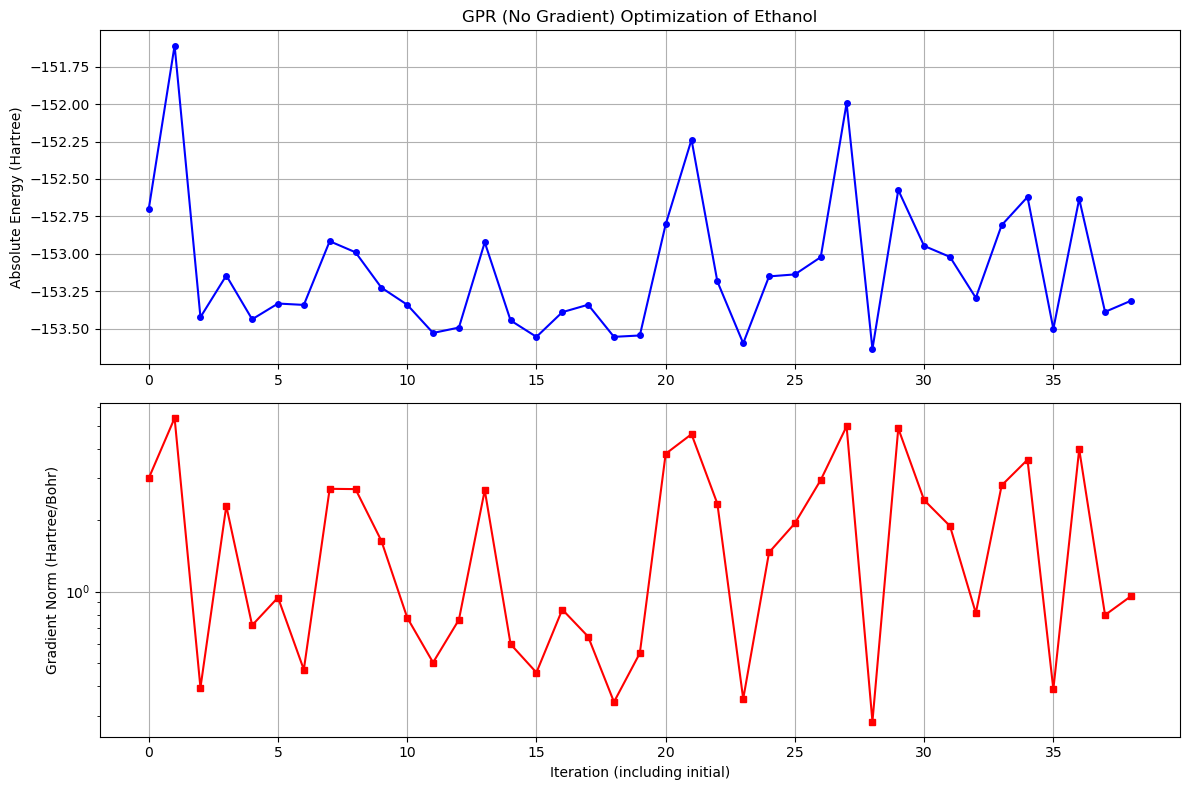

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from pyscf import gto, scf, grad
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
import warnings
warnings.filterwarnings('ignore')

# ------------------ 1. 生成乙醇初始分子（带扰动） ------------------
def get_ethanol_init(seed=42, perturb_strength=0.0):
    mol = Chem.MolFromSmiles('CCO')
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=seed)
    atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    conf = mol.GetConformer()
    coords = conf.GetPositions()
    if perturb_strength > 0:
        np.random.seed(seed)
        perturbation = np.random.uniform(-perturb_strength, perturb_strength, size=coords.shape)
        coords += perturbation
    return mol, atom_symbols, coords

perturb = 0.5
mol_rdkit, atom_symbols, init_coords_ang = get_ethanol_init(seed=42, perturb_strength=perturb)
natom = len(atom_symbols)
print("原子符号:", atom_symbols)
print(f"初始坐标（已扰动 ±{perturb} Å）:\n", init_coords_ang)

# ------------------ 2. 从扰动坐标提取内坐标 z0 ------------------
temp_mol = Chem.Mol(mol_rdkit)
conf_temp = temp_mol.GetConformer()
for i, (x, y, z) in enumerate(init_coords_ang):
    conf_temp.SetAtomPosition(i, (x, y, z))

# 原子顺序: 0:C1, 1:C2, 2:O, 3:H1(C1), 4:H2(C1), 5:H3(C1), 6:H4(C2), 7:H5(C2), 8:H6(O)
# 键长 (8个)
r01 = rdMolTransforms.GetBondLength(conf_temp, 0, 1)   # C1-C2
r12 = rdMolTransforms.GetBondLength(conf_temp, 1, 2)   # C2-O
r03 = rdMolTransforms.GetBondLength(conf_temp, 0, 3)   # C1-H1
r04 = rdMolTransforms.GetBondLength(conf_temp, 0, 4)   # C1-H2
r05 = rdMolTransforms.GetBondLength(conf_temp, 0, 5)   # C1-H3
r16 = rdMolTransforms.GetBondLength(conf_temp, 1, 6)   # C2-H4
r17 = rdMolTransforms.GetBondLength(conf_temp, 1, 7)   # C2-H5
r28 = rdMolTransforms.GetBondLength(conf_temp, 2, 8)   # O-H6

# 键角 (7个)
a103 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 1, 0, 3))   # C2-C1-H1
a104 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 1, 0, 4))   # C2-C1-H2
a105 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 1, 0, 5))   # C2-C1-H3
a016 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 0, 1, 6))   # C1-C2-H4
a017 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 0, 1, 7))   # C1-C2-H5
a012 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 0, 1, 2))   # C1-C2-O
a128 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 1, 2, 8))   # C2-O-H6

# 二面角 (6个)
d3016 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 3, 0, 1, 6))   # H1-C1-C2-H4
d4016 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 4, 0, 1, 6))   # H2-C1-C2-H4
d5016 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 5, 0, 1, 6))   # H3-C1-C2-H4
d3012 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 3, 0, 1, 2))   # H1-C1-C2-O
d4012 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 4, 0, 1, 2))   # H2-C1-C2-O
d5012 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 5, 0, 1, 2))   # H3-C1-C2-O

z0 = np.array([
    r01, r12, r03, r04, r05, r16, r17, r28,
    a103, a104, a105, a016, a017, a012, a128,
    d3016, d4016, d5016, d3012, d4012, d5012
])

# 全局合理边界
bounds_z = [
    (0.8, 2.0), (0.8, 2.0), (0.5, 1.5), (0.5, 1.5), (0.5, 1.5),
    (0.5, 1.5), (0.5, 1.5), (0.5, 1.5),
    (60, 180), (60, 180), (60, 180), (60, 180), (60, 180), (60, 180), (60, 180),
    (-180, 180), (-180, 180), (-180, 180), (-180, 180), (-180, 180), (-180, 180)
]

# 裁剪 z0 到全局边界内
lower = np.array([b[0] for b in bounds_z])
upper = np.array([b[1] for b in bounds_z])
z0 = np.clip(z0, lower, upper)

# 内坐标转笛卡尔函数（用于能量计算）
def zmatrix_to_cartesian(z):
    mol = Chem.Mol(mol_rdkit)
    conf = mol.GetConformer()
    rdMolTransforms.SetBondLength(conf, 0, 1, z[0])
    rdMolTransforms.SetBondLength(conf, 1, 2, z[1])
    rdMolTransforms.SetBondLength(conf, 0, 3, z[2])
    rdMolTransforms.SetBondLength(conf, 0, 4, z[3])
    rdMolTransforms.SetBondLength(conf, 0, 5, z[4])
    rdMolTransforms.SetBondLength(conf, 1, 6, z[5])
    rdMolTransforms.SetBondLength(conf, 1, 7, z[6])
    rdMolTransforms.SetBondLength(conf, 2, 8, z[7])
    rdMolTransforms.SetAngleRad(conf, 1, 0, 3, np.radians(z[8]))
    rdMolTransforms.SetAngleRad(conf, 1, 0, 4, np.radians(z[9]))
    rdMolTransforms.SetAngleRad(conf, 1, 0, 5, np.radians(z[10]))
    rdMolTransforms.SetAngleRad(conf, 0, 1, 6, np.radians(z[11]))
    rdMolTransforms.SetAngleRad(conf, 0, 1, 7, np.radians(z[12]))
    rdMolTransforms.SetAngleRad(conf, 0, 1, 2, np.radians(z[13]))
    rdMolTransforms.SetAngleRad(conf, 1, 2, 8, np.radians(z[14]))
    rdMolTransforms.SetDihedralRad(conf, 3, 0, 1, 6, np.radians(z[15]))
    rdMolTransforms.SetDihedralRad(conf, 4, 0, 1, 6, np.radians(z[16]))
    rdMolTransforms.SetDihedralRad(conf, 5, 0, 1, 6, np.radians(z[17]))
    rdMolTransforms.SetDihedralRad(conf, 3, 0, 1, 2, np.radians(z[18]))
    rdMolTransforms.SetDihedralRad(conf, 4, 0, 1, 2, np.radians(z[19]))
    rdMolTransforms.SetDihedralRad(conf, 5, 0, 1, 2, np.radians(z[20]))
    return conf.GetPositions()

# ------------------ 3. PySCF 能量和梯度计算（仅用于记录梯度，不用于模型） ------------------
def energy_grad_pyscf(atom_symbols, coords_ang):
    atom_str = '\n'.join([f"{atom_symbols[i]}  {coords_ang[i,0]:.8f}  {coords_ang[i,1]:.8f}  {coords_ang[i,2]:.8f}" 
                          for i in range(len(atom_symbols))])
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = 'cc-pvdz'
    mol.unit = 'angstrom'
    mol.build(verbose=0)
    mf = scf.RHF(mol)
    mf.kernel()
    energy = mf.e_tot
    g = grad.RHF(mf)
    grad_au = g.kernel()
    return energy, grad_au.flatten()

# ------------------ 4. 普通 GPR 优化器（内坐标，仅能量） ------------------
class GPROptimizer:
    def __init__(self, atom_symbols, z0, bounds_z, local_radius=0.5, n_init=10):
        self.atom_symbols = atom_symbols
        self.z0 = z0.copy()
        # 局部边界
        self.bounds = [(max(bounds_z[i][0], z0[i] - local_radius),
                        min(bounds_z[i][1], z0[i] + local_radius)) for i in range(len(z0))]
        # 边界有效性检查
        for i, (low, high) in enumerate(self.bounds):
            if low > high:
                print(f"警告：维度 {i} 边界无效，使用全局边界")
                self.bounds[i] = bounds_z[i]
        self.dim = len(z0)
        self.X = []
        self.y = []
        self.history = {'z': [], 'energy': [], 'grad_norm': []}
        self._generate_initial_samples(n_init)
        kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(self.dim), nu=2.5) + WhiteKernel(1e-3)
        self.gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5)
        self.best_energy = np.min(self.y)
        self.no_improve = 0

    def _generate_initial_samples(self, n_init):
        print("生成初始采样点...")
        for i in range(n_init):
            if i == 0:
                z = self.z0
            else:
                z = np.array([np.random.uniform(low, high) for low, high in self.bounds])
            coords = zmatrix_to_cartesian(z)
            e, g = energy_grad_pyscf(self.atom_symbols, coords)
            self.X.append(z.copy())
            self.y.append(e)
            self.history['z'].append(z)
            self.history['energy'].append(e)
            self.history['grad_norm'].append(np.linalg.norm(g))
            print(f"Init {i}: Energy = {e:.8f} Hartree, |grad| = {np.linalg.norm(g):.6f}")

    def _ei(self, x, xi=0.001):
        x = x.reshape(1, -1)
        mu, sigma = self.gpr.predict(x, return_std=True)
        sigma = sigma[0]
        if sigma == 0:
            return 0
        y_min = np.min(self.y)
        gamma = (y_min - mu - xi) / sigma
        return (y_min - mu - xi) * norm.cdf(gamma) + sigma * norm.pdf(gamma)

    def propose(self, n_restarts=10, xi=0.001):
        best_x, best_ei = None, -np.inf
        bounds = self.bounds
        for _ in range(n_restarts):
            x0 = np.array([np.random.uniform(low, high) for low, high in bounds])
            res = minimize(lambda x: -self._ei(x, xi), x0, bounds=bounds, method='L-BFGS-B')
            if res.success and -res.fun > best_ei:
                best_ei = -res.fun
                best_x = res.x
        return best_x

    def step(self, xi=0.001):
        z_next = self.propose(xi=xi)
        coords = zmatrix_to_cartesian(z_next)
        e, g = energy_grad_pyscf(self.atom_symbols, coords)
        self.X.append(z_next)
        self.y.append(e)
        self.history['z'].append(z_next)
        self.history['energy'].append(e)
        self.history['grad_norm'].append(np.linalg.norm(g))
        if e < self.best_energy - 1e-6:
            self.best_energy = e
            self.no_improve = 0
        else:
            self.no_improve += 1
        self.gpr.fit(np.array(self.X), np.array(self.y))
        return e, np.linalg.norm(g)

    def run(self, max_iter=30, xi=0.001, early_stop=10):
        self.gpr.fit(np.array(self.X), np.array(self.y))
        for i in range(max_iter):
            e, gnorm = self.step(xi=xi)
            print(f"Iter {i+1:2d}: Energy = {e:.8f} Hartree, |grad| = {gnorm:.6f}")
            if self.no_improve >= early_stop:
                print("早停：连续无改进")
                break
        best_idx = np.argmin(self.y)
        best_z = np.array(self.X)[best_idx]
        best_coords = zmatrix_to_cartesian(best_z)
        return best_coords, self.y[best_idx], self.history

# ------------------ 5. 运行优化 ------------------
print("="*60)
print("普通 GPR 优化（无梯度增强）")
print("="*60)
optimizer = GPROptimizer(atom_symbols, z0, bounds_z, local_radius=0.5, n_init=10)
best_coords, best_energy, history = optimizer.run(max_iter=30, xi=0.001, early_stop=10)

print("\n优化完成！")
print(f"最优能量: {best_energy:.8f} Hartree")
print("最优坐标 (Å):")
for i, sym in enumerate(atom_symbols):
    x, y, z = best_coords[i]
    print(f"{sym:2s}  {x:8.4f}  {y:8.4f}  {z:8.4f}")

# ------------------ 6. 可视化 ------------------
energies = np.array(history['energy'])
grad_norms = np.array(history['grad_norm'])
rel_energies = energies - energies[0]

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(energies, 'b-o', markersize=4)
plt.ylabel('Absolute Energy (Hartree)')
plt.title('GPR (No Gradient) Optimization of Ethanol')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogy(grad_norms, 'r-s', markersize=4)
plt.xlabel('Iteration (including initial)')
plt.ylabel('Gradient Norm (Hartree/Bohr)')
plt.grid(True)

plt.tight_layout()
plt.savefig('gpr_no_grad_ethanol.png', dpi=150)
plt.show()

原子符号: ['C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']
初始坐标（已扰动 ±0.5 Å）:
 [[-1.07891507  0.49851852  0.27449332]
 [ 0.58657717 -0.66552068 -0.53305522]
 [ 0.83506114  0.69095982  0.83878825]
 [-1.14894003  0.25455969 -0.26331271]
 [-1.2608783  -1.15023072 -0.29641556]
 [-1.38762677  0.4006816   1.03591919]
 [ 0.71935107 -0.34937954 -1.12392143]
 [ 0.22952174 -1.63396501 -0.17766864]
 [ 1.78855985  1.333001    0.08865603]]
GPy 梯度增强 GPR 优化
生成 GPy 初始采样点...
Init 0: Energy = -152.70016149 Hartree, |grad| = 2.999204
Init 1: Energy = -151.60814461 Hartree, |grad| = 5.374024
Init 2: Energy = -153.42392276 Hartree, |grad| = 0.393454
Init 3: Energy = -153.14555383 Hartree, |grad| = 2.291642
Init 4: Energy = -153.43796011 Hartree, |grad| = 0.721041
Init 5: Energy = -153.33269270 Hartree, |grad| = 0.943184
Init 6: Energy = -153.34192474 Hartree, |grad| = 0.468991
Init 7: Energy = -152.91613746 Hartree, |grad| = 2.706599
Init 8: Energy = -152.99026726 Hartree, |grad| = 2.698722
Init 9: Energy = -153.2

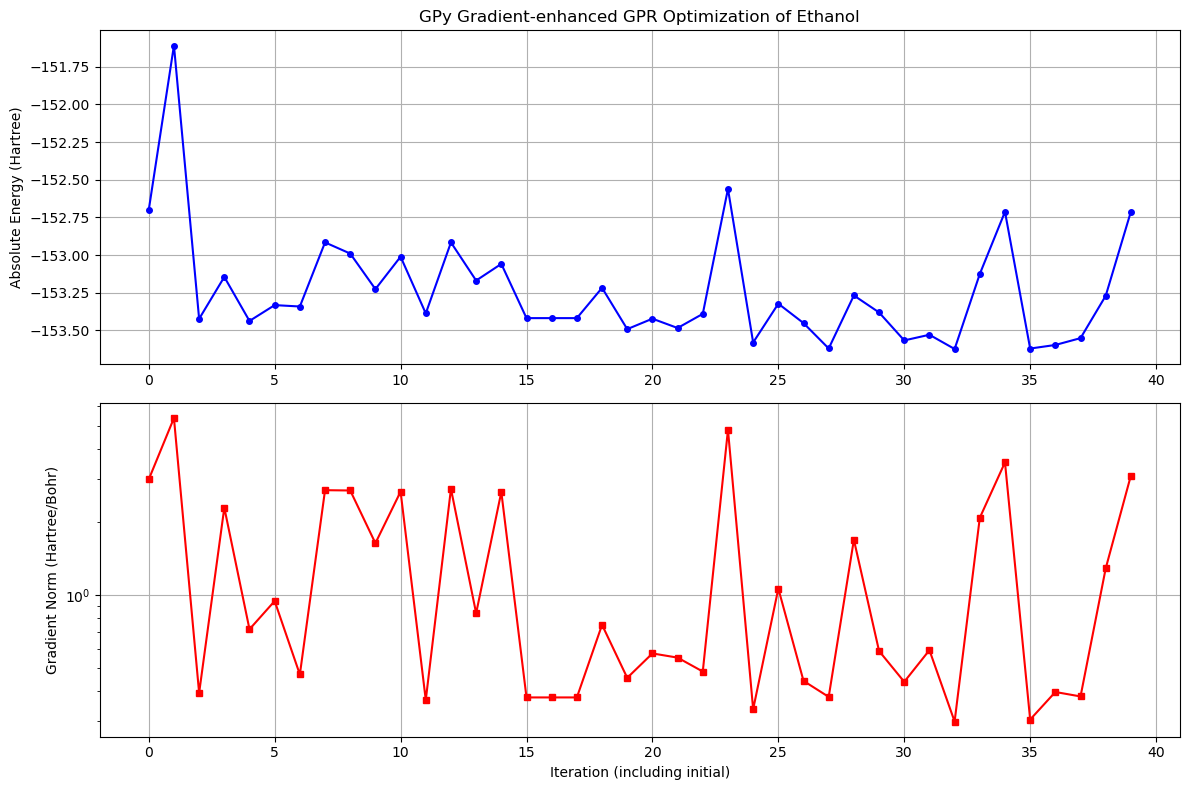

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from pyscf import gto, scf, grad
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
import GPy
import warnings
warnings.filterwarnings('ignore')

# ------------------ 1. 生成乙醇初始分子（带扰动） ------------------
def get_ethanol_init(seed=42, perturb_strength=0.0):
    mol = Chem.MolFromSmiles('CCO')
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=seed)
    atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    conf = mol.GetConformer()
    coords = conf.GetPositions()
    if perturb_strength > 0:
        np.random.seed(seed)
        perturbation = np.random.uniform(-perturb_strength, perturb_strength, size=coords.shape)
        coords += perturbation
    return mol, atom_symbols, coords

perturb = 0.5
mol_rdkit, atom_symbols, init_coords_ang = get_ethanol_init(seed=42, perturb_strength=perturb)
natom = len(atom_symbols)
print("原子符号:", atom_symbols)
print(f"初始坐标（已扰动 ±{perturb} Å）:\n", init_coords_ang)

# ------------------ 2. 从扰动坐标提取内坐标 z0 ------------------
temp_mol = Chem.Mol(mol_rdkit)
conf_temp = temp_mol.GetConformer()
for i, (x, y, z) in enumerate(init_coords_ang):
    conf_temp.SetAtomPosition(i, (x, y, z))

# 原子顺序: 0:C1, 1:C2, 2:O, 3:H1(C1), 4:H2(C1), 5:H3(C1), 6:H4(C2), 7:H5(C2), 8:H6(O)
# 键长 (8个)
r01 = rdMolTransforms.GetBondLength(conf_temp, 0, 1)   # C1-C2
r12 = rdMolTransforms.GetBondLength(conf_temp, 1, 2)   # C2-O
r03 = rdMolTransforms.GetBondLength(conf_temp, 0, 3)   # C1-H1
r04 = rdMolTransforms.GetBondLength(conf_temp, 0, 4)   # C1-H2
r05 = rdMolTransforms.GetBondLength(conf_temp, 0, 5)   # C1-H3
r16 = rdMolTransforms.GetBondLength(conf_temp, 1, 6)   # C2-H4
r17 = rdMolTransforms.GetBondLength(conf_temp, 1, 7)   # C2-H5
r28 = rdMolTransforms.GetBondLength(conf_temp, 2, 8)   # O-H6

# 键角 (7个)
a103 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 1, 0, 3))   # C2-C1-H1
a104 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 1, 0, 4))   # C2-C1-H2
a105 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 1, 0, 5))   # C2-C1-H3
a016 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 0, 1, 6))   # C1-C2-H4
a017 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 0, 1, 7))   # C1-C2-H5
a012 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 0, 1, 2))   # C1-C2-O
a128 = np.degrees(rdMolTransforms.GetAngleRad(conf_temp, 1, 2, 8))   # C2-O-H6

# 二面角 (6个)
d3016 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 3, 0, 1, 6))   # H1-C1-C2-H4
d4016 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 4, 0, 1, 6))   # H2-C1-C2-H4
d5016 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 5, 0, 1, 6))   # H3-C1-C2-H4
d3012 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 3, 0, 1, 2))   # H1-C1-C2-O
d4012 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 4, 0, 1, 2))   # H2-C1-C2-O
d5012 = np.degrees(rdMolTransforms.GetDihedralRad(conf_temp, 5, 0, 1, 2))   # H3-C1-C2-O

z0 = np.array([
    r01, r12, r03, r04, r05, r16, r17, r28,
    a103, a104, a105, a016, a017, a012, a128,
    d3016, d4016, d5016, d3012, d4012, d5012
])

# 全局合理边界
bounds_z = [
    (0.8, 2.0), (0.8, 2.0), (0.5, 1.5), (0.5, 1.5), (0.5, 1.5),
    (0.5, 1.5), (0.5, 1.5), (0.5, 1.5),
    (60, 180), (60, 180), (60, 180), (60, 180), (60, 180), (60, 180), (60, 180),
    (-180, 180), (-180, 180), (-180, 180), (-180, 180), (-180, 180), (-180, 180)
]

# 裁剪 z0 到全局边界内
lower = np.array([b[0] for b in bounds_z])
upper = np.array([b[1] for b in bounds_z])
z0 = np.clip(z0, lower, upper)

# 内坐标转笛卡尔函数
def zmatrix_to_cartesian(z):
    mol = Chem.Mol(mol_rdkit)
    conf = mol.GetConformer()
    rdMolTransforms.SetBondLength(conf, 0, 1, z[0])
    rdMolTransforms.SetBondLength(conf, 1, 2, z[1])
    rdMolTransforms.SetBondLength(conf, 0, 3, z[2])
    rdMolTransforms.SetBondLength(conf, 0, 4, z[3])
    rdMolTransforms.SetBondLength(conf, 0, 5, z[4])
    rdMolTransforms.SetBondLength(conf, 1, 6, z[5])
    rdMolTransforms.SetBondLength(conf, 1, 7, z[6])
    rdMolTransforms.SetBondLength(conf, 2, 8, z[7])
    rdMolTransforms.SetAngleRad(conf, 1, 0, 3, np.radians(z[8]))
    rdMolTransforms.SetAngleRad(conf, 1, 0, 4, np.radians(z[9]))
    rdMolTransforms.SetAngleRad(conf, 1, 0, 5, np.radians(z[10]))
    rdMolTransforms.SetAngleRad(conf, 0, 1, 6, np.radians(z[11]))
    rdMolTransforms.SetAngleRad(conf, 0, 1, 7, np.radians(z[12]))
    rdMolTransforms.SetAngleRad(conf, 0, 1, 2, np.radians(z[13]))
    rdMolTransforms.SetAngleRad(conf, 1, 2, 8, np.radians(z[14]))
    rdMolTransforms.SetDihedralRad(conf, 3, 0, 1, 6, np.radians(z[15]))
    rdMolTransforms.SetDihedralRad(conf, 4, 0, 1, 6, np.radians(z[16]))
    rdMolTransforms.SetDihedralRad(conf, 5, 0, 1, 6, np.radians(z[17]))
    rdMolTransforms.SetDihedralRad(conf, 3, 0, 1, 2, np.radians(z[18]))
    rdMolTransforms.SetDihedralRad(conf, 4, 0, 1, 2, np.radians(z[19]))
    rdMolTransforms.SetDihedralRad(conf, 5, 0, 1, 2, np.radians(z[20]))
    return conf.GetPositions()

# ------------------ 3. PySCF 能量和梯度计算 ------------------
def energy_grad_pyscf(atom_symbols, coords_ang):
    atom_str = '\n'.join([f"{atom_symbols[i]}  {coords_ang[i,0]:.8f}  {coords_ang[i,1]:.8f}  {coords_ang[i,2]:.8f}" 
                          for i in range(len(atom_symbols))])
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = 'cc-pvdz'
    mol.unit = 'angstrom'
    mol.build(verbose=0)
    mf = scf.RHF(mol)
    mf.kernel()
    energy = mf.e_tot
    g = grad.RHF(mf)
    grad_au = g.kernel()
    return energy, grad_au.flatten()

# ------------------ 4. GPy 梯度增强优化器 ------------------
class GPyGradientOptimizer:
    def __init__(self, atom_symbols, z0, bounds_z, local_radius=0.5, n_init=10):
        self.atom_symbols = atom_symbols
        self.z0 = z0.copy()
        self.bounds = [(max(bounds_z[i][0], z0[i] - local_radius),
                        min(bounds_z[i][1], z0[i] + local_radius)) for i in range(len(z0))]
        for i, (low, high) in enumerate(self.bounds):
            if low > high:
                print(f"警告：维度 {i} 边界无效，使用全局边界")
                self.bounds[i] = bounds_z[i]
        self.dim = len(z0)
        self.output_dim = 1 + 3 * natom
        self.X = []
        self.Y = []
        self.history = {'z': [], 'energy': [], 'grad_norm': []}
        self._generate_initial_samples(n_init)
        input_kernel = GPy.kern.Matern52(self.dim, ARD=True)
        coreg = GPy.kern.Coregionalize(input_dim=1, output_dim=self.output_dim, rank=5)
        kernel = input_kernel * coreg
        self.model = GPy.models.GPRegression(np.array(self.X), np.array(self.Y), kernel)
        self.model.Gaussian_noise.variance = 1e-4
        self.model.optimize(messages=False)
        self.best_energy = np.min([y[0] for y in self.Y])
        self.no_improve = 0

    def _generate_initial_samples(self, n_init):
        print("生成 GPy 初始采样点...")
        for i in range(n_init):
            if i == 0:
                z = self.z0
            else:
                z = np.array([np.random.uniform(low, high) for low, high in self.bounds])
            coords = zmatrix_to_cartesian(z)
            e, g = energy_grad_pyscf(self.atom_symbols, coords)
            y = np.hstack([[e], g])
            self.X.append(z.copy())
            self.Y.append(y)
            self.history['z'].append(z)
            self.history['energy'].append(e)
            self.history['grad_norm'].append(np.linalg.norm(g))
            print(f"Init {i}: Energy = {e:.8f} Hartree, |grad| = {np.linalg.norm(g):.6f}")

    def _ei(self, x, xi=0.001):
        x = x.reshape(1, -1)
        mu, var = self.model.predict(x)
        mu_e = mu[0, 0]
        sigma_e = np.sqrt(var[0, 0])
        if sigma_e == 0:
            return 0
        y_min = np.min([y[0] for y in self.Y])
        gamma = (y_min - mu_e - xi) / sigma_e
        return (y_min - mu_e - xi) * norm.cdf(gamma) + sigma_e * norm.pdf(gamma)

    def propose(self, n_restarts=10, xi=0.001):
        best_x, best_ei = None, -np.inf
        bounds = self.bounds
        for _ in range(n_restarts):
            x0 = np.array([np.random.uniform(low, high) for low, high in bounds])
            res = minimize(lambda x: -self._ei(x, xi), x0, bounds=bounds, method='L-BFGS-B')
            if res.success and -res.fun > best_ei:
                best_ei = -res.fun
                best_x = res.x
        return best_x

    def step(self, xi=0.001):
        z_next = self.propose(xi=xi)
        coords = zmatrix_to_cartesian(z_next)
        e, g = energy_grad_pyscf(self.atom_symbols, coords)
        y_next = np.hstack([[e], g])
        self.X.append(z_next)
        self.Y.append(y_next)
        self.history['z'].append(z_next)
        self.history['energy'].append(e)
        self.history['grad_norm'].append(np.linalg.norm(g))
        if e < self.best_energy - 1e-6:
            self.best_energy = e
            self.no_improve = 0
        else:
            self.no_improve += 1
        self.model.set_XY(np.array(self.X), np.array(self.Y))
        self.model.optimize(messages=False)
        return e, np.linalg.norm(g)

    def run(self, max_iter=30, xi=0.001, early_stop=10):
        for i in range(max_iter):
            e, gnorm = self.step(xi=xi)
            print(f"Iter {i+1:2d}: Energy = {e:.8f} Hartree, |grad| = {gnorm:.6f}")
            if self.no_improve >= early_stop:
                print("早停：连续无改进")
                break
        best_idx = np.argmin([y[0] for y in self.Y])
        best_z = np.array(self.X)[best_idx]
        best_coords = zmatrix_to_cartesian(best_z)
        return best_coords, self.Y[best_idx][0], self.history

# ------------------ 5. 运行优化 ------------------
print("="*60)
print("GPy 梯度增强 GPR 优化")
print("="*60)
optimizer = GPyGradientOptimizer(atom_symbols, z0, bounds_z, local_radius=0.5, n_init=10)
best_coords, best_energy, history = optimizer.run(max_iter=30, xi=0.001, early_stop=10)

print("\n优化完成！")
print(f"最优能量: {best_energy:.8f} Hartree")
print("最优坐标 (Å):")
for i, sym in enumerate(atom_symbols):
    x, y, z = best_coords[i]
    print(f"{sym:2s}  {x:8.4f}  {y:8.4f}  {z:8.4f}")

# ------------------ 6. 可视化 ------------------
energies = np.array(history['energy'])
grad_norms = np.array(history['grad_norm'])
rel_energies = energies - energies[0]

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(energies, 'b-o', markersize=4)
plt.ylabel('Absolute Energy (Hartree)')
plt.title('GPy Gradient-enhanced GPR Optimization of Ethanol')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogy(grad_norms, 'r-s', markersize=4)
plt.xlabel('Iteration (including initial)')
plt.ylabel('Gradient Norm (Hartree/Bohr)')
plt.grid(True)

plt.tight_layout()
plt.savefig('gpy_gpr_ethanol.png', dpi=150)
plt.show()